In [41]:
import sklearn
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#no wrapping
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)  # Disable line-wrapping
pd.set_option('display.max_rows', 10)


coffea_caff = pd.read_csv(r"..\data\cleaned_data_w_class.csv")
#coffea_caff = pd.read_csv(r"..\data\cleaned_data_num_w_class.csv")
#coffea_caff_clim = pd.read_csv(r"..\data\coll_caff_node_clim_w_class.csv")
#coffea_caff_env = pd.read_csv(r"..\data\coll_caff_node_env_w_class.csv")

coffee_data = coffea_caff.copy()

#distinct_vals = coffee_data['caffeine_class'].value_counts()
#print(distinct_vals)

coffee_data.describe()

,clim_1_tmin1_jan,clim_2_tmin2_feb,clim_3_tmin3_mar,clim_4_tmin4_apr,clim_5_tmin5_may,clim_6_tmin6_jun,clim_7_tmin7_jul,clim_8_tmin8_aug,clim_9_tmin9_sep,clim_10_tmin10_oct,...,env_78_wat_22,env_78_wat_17,env_78_wat_1.1,env_78_wat_18,env_78_wat_15,env_78_wat_19,env_78_wat_24,env_78_wat_0,caffeine_percent,caffeine_class
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,...,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,214.402222,214.428889,210.337778,199.320000,175.922222,158.626667,153.960000,156.686667,166.244444,198.446667,...,0.004444,0.006667,0.006667,0.006667,0.004444,0.008889,0.002222,0.053333,0.017122,0.208889
std,18.827413,19.069106,20.203125,24.535775,30.292350,30.925418,30.358852,28.804263,27.058261,22.760358,...,0.066592,0.081468,0.081468,0.081468,0.066592,0.093965,0.047140,0.224947,0.087017,0.406967
min,136.500000,136.000000,136.000000,126.000000,104.000000,85.000000,81.000000,82.000000,81.000000,112.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,210.625000,210.000000,202.000000,183.250000,155.000000,140.000000,134.000000,138.000000,150.000000,190.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,219.500000,220.000000,216.000000,204.000000,180.000000,159.000000,156.000000,161.500000,169.000000,201.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,226.500000,227.000000,224.000000,218.000000,197.000000,181.000000,177.000000,178.750000,188.000000,214.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,242.000000,242.000000,242.000000,241.000000,234.000000,219.000000,209.000000,208.000000,213.000000,236.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.700000,1.000000


To address correlated features, I will first separate numerical and one-hot encoded features


In [42]:
categ_col = coffee_data.filter(regex='^env_(75|76|77|78)').columns.tolist()

num_data = coffee_data.drop(columns=categ_col)
categ_data = coffee_data[categ_col]

print(categ_data.describe())

num_data.describe()

       env_75_geo_1_1  env_75_geo_10  env_75_geo_9  env_75_geo_7  env_75_geo_6  env_75_geo_5  env_75_geo_11  env_75_geo_2  env_75_geo_0  env_76_soi_5  ...  env_78_wat_14  env_78_wat_13  env_78_wat_22  env_78_wat_17  env_78_wat_1.1  env_78_wat_18  env_78_wat_15  env_78_wat_19  env_78_wat_24  env_78_wat_0
count      450.000000     450.000000    450.000000    450.000000    450.000000    450.000000     450.000000    450.000000    450.000000    450.000000  ...     450.000000     450.000000     450.000000     450.000000      450.000000     450.000000     450.000000     450.000000     450.000000    450.000000
mean         0.057778       0.386667      0.135556      0.124444      0.122222      0.037778       0.004444      0.068889      0.062222      0.002222  ...       0.011111       0.037778       0.004444       0.006667        0.006667       0.006667       0.004444       0.008889       0.002222      0.053333
std          0.233582       0.487528      0.342697      0.330455      0.327907      0

,clim_1_tmin1_jan,clim_2_tmin2_feb,clim_3_tmin3_mar,clim_4_tmin4_apr,clim_5_tmin5_may,clim_6_tmin6_jun,clim_7_tmin7_jul,clim_8_tmin8_aug,clim_9_tmin9_sep,clim_10_tmin10_oct,...,clim_68_pet_annual,clim_69_cwd_annual,clim_70_ndm_per_year,env_71_alt,env_72_slo,env_73_asp,env_74_solrad,env_79_forcov,caffeine_percent,caffeine_class
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,...,450.000000,450.000000,450.00000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,214.402222,214.428889,210.337778,199.320000,175.922222,158.626667,153.960000,156.686667,166.244444,198.446667,...,1252.891111,309.568889,5.20000,264.273333,6.942222,191.148889,7603.668889,34.313333,0.017122,0.208889
std,18.827413,19.069106,20.203125,24.535775,30.292350,30.925418,30.358852,28.804263,27.058261,22.760358,...,206.998228,307.731583,3.89506,312.934631,6.142426,100.221948,328.454021,35.737001,0.087017,0.406967
min,136.500000,136.000000,136.000000,126.000000,104.000000,85.000000,81.000000,82.000000,81.000000,112.000000,...,764.000000,0.000000,0.00000,0.000000,0.000000,0.000000,6070.000000,0.000000,0.000000,0.000000
25%,210.625000,210.000000,202.000000,183.250000,155.000000,140.000000,134.000000,138.000000,150.000000,190.000000,...,1133.250000,20.000000,1.00000,60.000000,2.000000,123.000000,7431.250000,1.250000,0.000000,0.000000
50%,219.500000,220.000000,216.000000,204.000000,180.000000,159.000000,156.000000,161.500000,169.000000,201.000000,...,1226.500000,205.000000,7.00000,142.000000,5.000000,201.000000,7635.000000,18.000000,0.000000,0.000000
75%,226.500000,227.000000,224.000000,218.000000,197.000000,181.000000,177.000000,178.750000,188.000000,214.000000,...,1402.000000,612.000000,8.00000,321.000000,10.000000,268.750000,7805.000000,62.000000,0.000000,0.000000
max,242.000000,242.000000,242.000000,241.000000,234.000000,219.000000,209.000000,208.000000,213.000000,236.000000,...,1829.000000,960.000000,12.00000,1652.000000,34.000000,358.000000,8436.000000,100.000000,0.700000,1.000000


In [43]:
import pandas as pd
import numpy as np    # <-- import numpy yourself

# suppose `df_dummies` is your one-hot–encoded DataFrame
corr = categ_data.corr()

# build a mask to ignore the diagonal
mask = ~np.eye(len(corr), dtype=bool)

# stack the off-diagonal correlations and filter by threshold
high_corr = (
    corr.where(mask)      # keep only off-diagonal entries
        .stack()          # turn into a Series with MultiIndex (i, j)
        .loc[lambda s: s.abs() > 0.8]  # pick abs(corr) > 0.8
)

print(high_corr)


env_76_soi_13  env_78_wat_24    1.0
env_78_wat_24  env_76_soi_13    1.0
dtype: float64


In [46]:
from sklearn.ensemble import RandomForestClassifier  # or Regressor
X = coffee_data.drop(columns=["caffeine_class", "caffeine_percent"])
y = coffee_data["caffeine_class"]

rf = RandomForestClassifier(random_state=0)
rf.fit(X, y)

importances = (pd
    .Series(rf.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
)
pd.set_option('display.max_rows', None)

print(importances)


env_75_geo_10               0.037166
clim_34_prec10_oct          0.033222
clim_53_prec_driest_q       0.025788
clim_56_pet1_jan            0.025711
clim_19_tmax7_jul           0.023700
clim_40_temp_season         0.021965
clim_28_prec4_apr           0.021646
clim_50_prec_driest_m       0.020262
clim_32_prec8_aug           0.019706
clim_27_prec3_mar           0.018660
clim_31_prec7_jul           0.018464
clim_33_prec9_sep           0.018228
env_71_alt                  0.017662
clim_29_prec5_may           0.017086
clim_54_prec_warmest_q      0.016943
clim_21_tmax9_sep           0.016078
clim_49_prec_wettest_m      0.015794
clim_48_Annual_prec         0.015495
env_74_solrad               0.015425
clim_69_cwd_annual          0.014811
clim_30_prec6_jun           0.014765
clim_52_prec_wettest_q      0.014750
clim_23_tmax11_nov          0.014733
clim_41_tmax_warmest_m      0.014048
clim_35_prec11_nov          0.013897
env_73_asp                  0.013665
clim_55_prec_coldest_q      0.013408
c

In [ ]:
pd.set_option('display.max_rows', 60)


In [47]:
def list_highly_correlated_pairs(df, threshold=0.9):
    """
    Lists highly correlated feature pairs in the DataFrame above a given threshold.

    Parameters:
    - df: DataFrame with numeric features
    - threshold: correlation threshold

    Returns:
    - List of tuples (feature_1, feature_2, correlation_value)
    """
    corr_matrix = df.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    correlated_pairs = []

    for col in upper_tri.columns:
        high_corr = upper_tri.index[upper_tri[col] > threshold].tolist()
        for row in high_corr:
            correlated_pairs.append((row, col, corr_matrix.loc[row, col]))

    return correlated_pairs




In [48]:
high_corr_pairs = list_highly_correlated_pairs(num_data, threshold=0.95)

# Display results
for f1, f2, corr in high_corr_pairs:
    print(f"{f1} and {f2} | correlation = {corr:.2f}")

clim_1_tmin1_jan and clim_2_tmin2_feb | correlation = 1.00
clim_1_tmin1_jan and clim_3_tmin3_mar | correlation = 0.98
clim_2_tmin2_feb and clim_3_tmin3_mar | correlation = 0.98
clim_3_tmin3_mar and clim_4_tmin4_apr | correlation = 0.97
clim_4_tmin4_apr and clim_5_tmin5_may | correlation = 0.96
clim_4_tmin4_apr and clim_6_tmin6_jun | correlation = 0.95
clim_5_tmin5_may and clim_6_tmin6_jun | correlation = 1.00
clim_4_tmin4_apr and clim_7_tmin7_jul | correlation = 0.96
clim_5_tmin5_may and clim_7_tmin7_jul | correlation = 0.99
clim_6_tmin6_jun and clim_7_tmin7_jul | correlation = 0.99
clim_4_tmin4_apr and clim_8_tmin8_aug | correlation = 0.98
clim_5_tmin5_may and clim_8_tmin8_aug | correlation = 0.99
clim_6_tmin6_jun and clim_8_tmin8_aug | correlation = 0.98
clim_7_tmin7_jul and clim_8_tmin8_aug | correlation = 0.99
clim_3_tmin3_mar and clim_9_tmin9_sep | correlation = 0.96
clim_4_tmin4_apr and clim_9_tmin9_sep | correlation = 0.99
clim_5_tmin5_may and clim_9_tmin9_sep | correlation = 0.

Format report for LaTeX

Correlation plots

In [49]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_correlation_network(df, threshold=0.85):
    """
    Plot a network graph where features are nodes and high correlations are edges.

    Parameters:
    - df: DataFrame with numeric features
    - threshold: minimum absolute correlation to draw an edge
    """
    corr_matrix = df.corr()
    G = nx.Graph()

    # Add edges for strong correlations
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                G.add_edge(corr_matrix.columns[i], corr_matrix.columns[j],
                           weight=corr_matrix.iloc[i, j])

    # Draw
    pos = nx.spring_layout(G, seed=42)  # Nice layout
    edges, weights = zip(*nx.get_edge_attributes(G, 'weight').items())

    plt.figure(figsize=(14, 10))
    nx.draw(G, pos, node_color='lightblue', node_size=1000,
            edgelist=edges, edge_color=weights,
            width=3, edge_cmap=plt.cm.coolwarm, with_labels=True, font_size=10)
    plt.title(f"Feature Correlation Network (|r| > {threshold})", fontsize=16)
    plt.show()




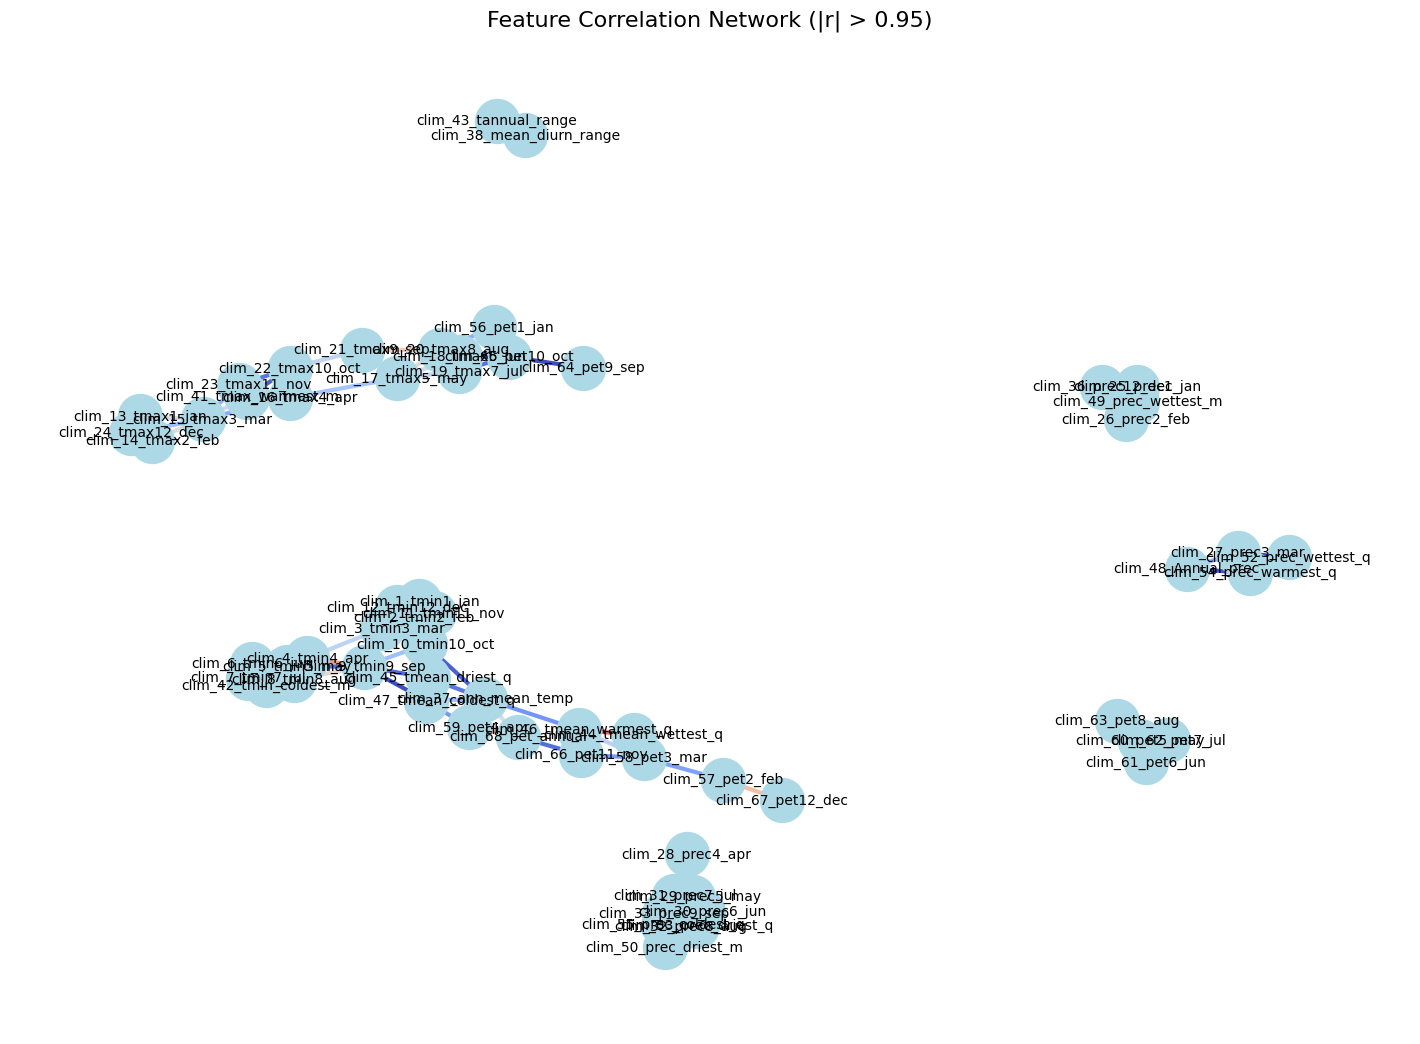

In [50]:
plot_correlation_network(num_data, threshold=0.95)


In [51]:
import networkx as nx

def extract_feature_clusters(df, threshold=0.85):
    """
    Find clusters (groups of correlated features) based on correlation threshold.

    Parameters:
    - df: DataFrame with numeric features
    - threshold: minimum absolute correlation to connect features

    Returns:
    - List of clusters (each cluster is a list of feature names)
    """
    corr_matrix = df.corr()
    G = nx.Graph()

    # Add edges for strong correlations
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                G.add_edge(corr_matrix.columns[i], corr_matrix.columns[j])

    # Find connected components (clusters)
    clusters = list(nx.connected_components(G))

    # Convert from sets to sorted lists for easier reading
    cluster_list = [sorted(list(cluster)) for cluster in clusters]

    # Sort clusters by size descending
    cluster_list = sorted(cluster_list, key=lambda x: len(x), reverse=True)

    print(f"✅ Found {len(cluster_list)} feature clusters.")

    return cluster_list



In [52]:
clusters = extract_feature_clusters(num_data, threshold=0.95)

# To display:
for idx, cluster in enumerate(clusters, 1):
    print(f"Cluster {idx} ({len(cluster)} features): {cluster}")


✅ Found 7 feature clusters.
Cluster 1 (24 features): ['clim_10_tmin10_oct', 'clim_11_tmin11_nov', 'clim_12_tmin12_dec', 'clim_1_tmin1_jan', 'clim_2_tmin2_feb', 'clim_37_ann_mean_temp', 'clim_3_tmin3_mar', 'clim_42_tmin_coldest_m', 'clim_44_tmean_wettest_q', 'clim_45_tmean_driest_q', 'clim_46_tmean_warmest_q', 'clim_47_tmean_coldest_q', 'clim_4_tmin4_apr', 'clim_57_pet2_feb', 'clim_58_pet3_mar', 'clim_59_pet4_apr', 'clim_5_tmin5_may', 'clim_66_pet11_nov', 'clim_67_pet12_dec', 'clim_68_pet_annual', 'clim_6_tmin6_jun', 'clim_7_tmin7_jul', 'clim_8_tmin8_aug', 'clim_9_tmin9_sep']
Cluster 2 (16 features): ['clim_13_tmax1_jan', 'clim_14_tmax2_feb', 'clim_15_tmax3_mar', 'clim_16_tmax4_apr', 'clim_17_tmax5_may', 'clim_18_tmax6_jun', 'clim_19_tmax7_jul', 'clim_20_tmax8_aug', 'clim_21_tmax9_sep', 'clim_22_tmax10_oct', 'clim_23_tmax11_nov', 'clim_24_tmax12_dec', 'clim_41_tmax_warmest_m', 'clim_56_pet1_jan', 'clim_64_pet9_sep', 'clim_65_pet10_oct']
Cluster 3 (9 features): ['clim_28_prec4_apr', 'cli

In [53]:
clusters = extract_feature_clusters(num_data, threshold=0.90)

# To display:
for idx, cluster in enumerate(clusters, 1):
    print(f"Cluster {idx} ({len(cluster)} features): {cluster}")

✅ Found 3 feature clusters.
Cluster 1 (46 features): ['clim_10_tmin10_oct', 'clim_11_tmin11_nov', 'clim_12_tmin12_dec', 'clim_13_tmax1_jan', 'clim_14_tmax2_feb', 'clim_15_tmax3_mar', 'clim_16_tmax4_apr', 'clim_17_tmax5_may', 'clim_18_tmax6_jun', 'clim_19_tmax7_jul', 'clim_1_tmin1_jan', 'clim_20_tmax8_aug', 'clim_21_tmax9_sep', 'clim_22_tmax10_oct', 'clim_23_tmax11_nov', 'clim_24_tmax12_dec', 'clim_2_tmin2_feb', 'clim_37_ann_mean_temp', 'clim_3_tmin3_mar', 'clim_40_temp_season', 'clim_41_tmax_warmest_m', 'clim_42_tmin_coldest_m', 'clim_44_tmean_wettest_q', 'clim_45_tmean_driest_q', 'clim_46_tmean_warmest_q', 'clim_47_tmean_coldest_q', 'clim_4_tmin4_apr', 'clim_56_pet1_jan', 'clim_57_pet2_feb', 'clim_58_pet3_mar', 'clim_59_pet4_apr', 'clim_5_tmin5_may', 'clim_60_pet5_may', 'clim_61_pet6_jun', 'clim_62_pet7_jul', 'clim_63_pet8_aug', 'clim_64_pet9_sep', 'clim_65_pet10_oct', 'clim_66_pet11_nov', 'clim_67_pet12_dec', 'clim_68_pet_annual', 'clim_6_tmin6_jun', 'clim_7_tmin7_jul', 'clim_8_tmin8

In [54]:
clusters = extract_feature_clusters(num_data, threshold=0.99)

# To display:
for idx, cluster in enumerate(clusters, 1):
    print(f"Cluster {idx} ({len(cluster)} features): {cluster}")

✅ Found 5 feature clusters.
Cluster 1 (6 features): ['clim_30_prec6_jun', 'clim_31_prec7_jul', 'clim_32_prec8_aug', 'clim_33_prec9_sep', 'clim_53_prec_driest_q', 'clim_55_prec_coldest_q']
Cluster 2 (5 features): ['clim_42_tmin_coldest_m', 'clim_5_tmin5_may', 'clim_6_tmin6_jun', 'clim_7_tmin7_jul', 'clim_8_tmin8_aug']
Cluster 3 (3 features): ['clim_12_tmin12_dec', 'clim_1_tmin1_jan', 'clim_2_tmin2_feb']
Cluster 4 (3 features): ['clim_13_tmax1_jan', 'clim_14_tmax2_feb', 'clim_24_tmax12_dec']
Cluster 5 (2 features): ['clim_44_tmean_wettest_q', 'clim_46_tmean_warmest_q']


Automatic cluster selection 
- per variance
- feature importance (RFC)

In [55]:
def automatic_cluster_feature_selection(df, method="variance", threshold=0.85, feature_importances=None):
    """
    Automatically select best feature from each feature cluster.

    Parameters:
    - df: DataFrame with numeric features
    - method: "variance" or "importance" (default: "variance")
    - threshold: correlation threshold to define clusters
    - feature_importances: dict {feature_name: importance_score} (only needed if method="importance")

    Returns:
    - Cleaned DataFrame with selected features
    """
    clusters = extract_feature_clusters(df, threshold=threshold)
    features_to_keep = []

    for idx, cluster in enumerate(clusters, 1):
        if len(cluster) == 1:
            features_to_keep.append(cluster[0])
            continue

        if method == "variance":
            variances = df[cluster].var()
            selected = variances.idxmax()
        
        elif method == "importance":
            if feature_importances is None:
                raise ValueError("Feature importances must be provided for 'importance' selection method.")
            importance_scores = {feat: feature_importances.get(feat, 0) for feat in cluster}
            selected = max(importance_scores, key=importance_scores.get)

        features_to_keep.append(selected)

    # Keep also untouched features
    clustered_features = set(f for cluster in clusters for f in cluster)
    untouched_features = [f for f in df.columns if f not in clustered_features]
    final_features = features_to_keep + untouched_features

    print(f"\n✅ Automatically selected {len(features_to_keep)} features from clusters. Final feature count: {len(final_features)}")
    return df[final_features], features_to_keep


In [56]:
df_final_auto, kept_features = automatic_cluster_feature_selection(num_data, method="variance", threshold=0.95)

kept_features

✅ Found 7 feature clusters.

✅ Automatically selected 7 features from clusters. Final feature count: 21


['clim_68_pet_annual',
 'clim_21_tmax9_sep',
 'clim_55_prec_coldest_q',
 'clim_49_prec_wettest_m',
 'clim_48_Annual_prec',
 'clim_60_pet5_may',
 'clim_43_tannual_range']

In [57]:
df_num_clean = df_final_auto.drop(columns=['caffeine_class', 'caffeine_percent']).columns


In [58]:
import pandas as pd
import numpy as np

def clean_features(
    df,
    kept_features,
    outcome_cols=['caffeine_class', 'caffeine_percent'],
    categ_regex=r'^env_(75|76|77|78)'
):
    """
    Selects exactly the user-specified continuous features plus:
      • all binary (nunique==2) columns
      • all env_* categorical columns matching categ_regex
    Drops outcome_cols before selection, then adds them back at the end.

    Parameters
    ----------
    df : pd.DataFrame
        Original DataFrame containing numeric features, env_* cats, and outcome_cols.
    kept_features : list of str
        Names of continuous numeric features you wish to retain.
    outcome_cols : list of str
        Columns to temporarily drop and then append at the end.
    categ_regex : str
        Regex to select additional categorical env columns (e.g. soil, rock, water).

    Returns
    -------
    pd.DataFrame
        clean_df with columns in this order:
        [kept_features + binary_features + env_categs + outcome_cols]
    """

    # 1. Separate out the outcomes
    outcomes = df[outcome_cols].copy()
    df_body = df.drop(columns=outcome_cols)

    # 2. Pull off the env_* categorical subset
    env_cats = df_body.filter(regex=categ_regex).copy()
    num_body = df_body.drop(columns=env_cats.columns)

    # 3. Split numeric into binary vs continuous
    binary_cols = num_body.columns[num_body.nunique() == 2].tolist()
    cont_cols   = num_body.columns[num_body.nunique() > 2].tolist()

    # 4. Validate kept_features against the true continuous set
    missing = set(kept_features) - set(cont_cols)
    if missing:
        raise ValueError(
            f"These kept_features are not in your continuous columns: {sorted(missing)}"
        )

    # 5. Subset each piece
    keep_cont   = num_body[kept_features]
    keep_binary = num_body[binary_cols]

    # 6. Re-assemble
    clean_df = pd.concat(
        [keep_cont, keep_binary, env_cats, outcomes],
        axis=1
    )

    print(f"Kept {len(kept_features)} continuous, "
          f"{len(binary_cols)} binary, "
          f"{env_cats.shape[1]} env_cats, "
          f"and {len(outcome_cols)} outcomes → total {clean_df.shape[1]} cols.")

    return clean_df



In [59]:
df_clean = clean_features(coffee_data, df_num_clean)


Kept 19 continuous, 0 binary, 69 env_cats, and 2 outcomes → total 90 cols.


In [60]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

column_names = num_data.drop(columns=['caffeine_class', 'caffeine_percent']).columns

# Define X and y
y = num_data['caffeine_class']
X = num_data.copy()

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get feature importances
importances = model.feature_importances_

# Use the stored column names to map the importances back to the feature names
important_features = sorted(zip(column_names, importances), key=lambda x: x[1], reverse=True)
feature_importance_dict = {feature: importance for feature, importance in zip(column_names, importances)}

# Display the most important features
#for feature, importance in important_features:
#    print(f"Feature: {feature}, Importance: {importance:.4f}")

In [61]:
# Using trained RandomForest model
feature_importance_dict = dict(zip(df_clean.columns, model.feature_importances_))

df_final_auto, kept_features = automatic_cluster_feature_selection(num_data, method="importance", threshold=0.95, feature_importances=feature_importance_dict)

kept_features


✅ Found 7 feature clusters.

✅ Automatically selected 7 features from clusters. Final feature count: 21


['clim_68_pet_annual',
 'clim_21_tmax9_sep',
 'clim_55_prec_coldest_q',
 'clim_49_prec_wettest_m',
 'clim_48_Annual_prec',
 'clim_60_pet5_may',
 'clim_43_tannual_range']

Cluster summary table

In [62]:
import pandas as pd

def create_cluster_summary_table(clusters, selected_features):
    """
    Create a clean DataFrame summarizing clusters and selected features.

    Parameters:
    - clusters: List of clusters (list of feature lists)
    - selected_features: List of selected feature names (one per cluster)

    Returns:
    - DataFrame with Cluster ID, Features in Cluster, Selected Feature
    """
    summary = []

    for idx, (cluster, selected) in enumerate(zip(clusters, selected_features), start=1):
        summary.append({
            "Cluster ID": idx,
            "Cluster Size": len(cluster),
            "Features in Cluster": ', '.join(cluster),
            "Selected Feature": selected
        })

    summary_df = pd.DataFrame(summary)

    print("\n📄 Cluster Summary Table:")
    display(summary_df)

    return summary_df




In [63]:
clusters = extract_feature_clusters(num_data, threshold=0.95)
summary_df = create_cluster_summary_table(clusters, kept_features)
#summary_df.to_csv("cluster_summary_table.csv", index=False)

✅ Found 7 feature clusters.

📄 Cluster Summary Table:


,Cluster ID,Cluster Size,Features in Cluster,Selected Feature
0,1,24,"clim_10_tmin10_oct, clim_11_tmin11_nov, clim_12_tmin12_dec, clim_1_tmin1_jan, clim_2_tmin2_feb, clim_37_ann_mean_temp, clim_3_tmin3_mar, clim_42_tmin_coldest_m, clim_44_tmean_wettest_q, clim_45_tmean_driest_q, clim_46_tmean_warmest_q, clim_47_tmean_coldest_q, clim_4_tmin4_apr, clim_57_pet2_feb, clim_58_pet3_mar, clim_59_pet4_apr, clim_5_tmin5_may, clim_66_pet11_nov, clim_67_pet12_dec, clim_68_pet_annual, clim_6_tmin6_jun, clim_7_tmin7_jul, clim_8_tmin8_aug, clim_9_tmin9_sep",clim_68_pet_annual
1,2,16,"clim_13_tmax1_jan, clim_14_tmax2_feb, clim_15_tmax3_mar, clim_16_tmax4_apr, clim_17_tmax5_may, clim_18_tmax6_jun, clim_19_tmax7_jul, clim_20_tmax8_aug, clim_21_tmax9_sep, clim_22_tmax10_oct, clim_23_tmax11_nov, clim_24_tmax12_dec, clim_41_tmax_warmest_m, clim_56_pet1_jan, clim_64_pet9_sep, clim_65_pet10_oct",clim_21_tmax9_sep
2,3,9,"clim_28_prec4_apr, clim_29_prec5_may, clim_30_prec6_jun, clim_31_prec7_jul, clim_32_prec8_aug, clim_33_prec9_sep, clim_50_prec_driest_m, clim_53_prec_driest_q, clim_55_prec_coldest_q",clim_55_prec_coldest_q
3,4,4,"clim_25_prec1_jan, clim_26_prec2_feb, clim_36_prec12_dec, clim_49_prec_wettest_m",clim_49_prec_wettest_m
4,5,4,"clim_27_prec3_mar, clim_48_Annual_prec, clim_52_prec_wettest_q, clim_54_prec_warmest_q",clim_48_Annual_prec
5,6,4,"clim_60_pet5_may, clim_61_pet6_jun, clim_62_pet7_jul, clim_63_pet8_aug",clim_60_pet5_may
6,7,2,"clim_38_mean_diurn_range, clim_43_tannual_range",clim_43_tannual_range


In [22]:
latex_code = summary_df.to_latex(index=False, 
                                 caption="Feature clusters and selected representative features after correlation-based dimensionality reduction.",
                                 label="tab:feature_selection_clusters",
                                 longtable=False,
                                 escape=False)


In [23]:
latex_code


'\\begin{table}\n\\caption{Feature clusters and selected representative features after correlation-based dimensionality reduction.}\n\\label{tab:feature_selection_clusters}\n\\begin{tabular}{rrll}\n\\toprule\nCluster ID & Cluster Size & Features in Cluster & Selected Feature \\\\\n\\midrule\n1 & 24 & clim_10_tmin10_oct, clim_11_tmin11_nov, clim_12_tmin12_dec, clim_1_tmin1_jan, clim_2_tmin2_feb, clim_37_ann_mean_temp, clim_3_tmin3_mar, clim_42_tmin_coldest_m, clim_44_tmean_wettest_q, clim_45_tmean_driest_q, clim_46_tmean_warmest_q, clim_47_tmean_coldest_q, clim_4_tmin4_apr, clim_57_pet2_feb, clim_58_pet3_mar, clim_59_pet4_apr, clim_5_tmin5_may, clim_66_pet11_nov, clim_67_pet12_dec, clim_68_pet_annual, clim_6_tmin6_jun, clim_7_tmin7_jul, clim_8_tmin8_aug, clim_9_tmin9_sep & clim_68_pet_annual \\\\\n2 & 16 & clim_13_tmax1_jan, clim_14_tmax2_feb, clim_15_tmax3_mar, clim_16_tmax4_apr, clim_17_tmax5_may, clim_18_tmax6_jun, clim_19_tmax7_jul, clim_20_tmax8_aug, clim_21_tmax9_sep, clim_22_tmax

In [64]:
column_mapping_df = pd.read_csv('../input/column_mapping.csv')
feature_mapping = dict(zip(column_mapping_df['new_name'], column_mapping_df['long_name']))


In [65]:
def map_feature_names(feature_list_str, mapping):
    features = [f.strip() for f in feature_list_str.split(',')]
    mapped = [mapping.get(f, f) for f in features]
    return ', '.join(mapped)


In [66]:
summary_df['Features in Cluster'] = summary_df['Features in Cluster'].apply(lambda x: map_feature_names(x, feature_mapping))
summary_df['Selected Feature'] = summary_df['Selected Feature'].map(lambda x: feature_mapping.get(x, x))


In [67]:
latex_table = summary_df.to_latex(index=False,
                                  caption="Feature clusters and selected representative features used in the final model, with ecologically interpretable labels.",
                                  label="tab:feature_selection_clusters_named",
                                  longtable=False,
                                  escape=False)


In [28]:
latex_table

'\\begin{table}\n\\caption{Feature clusters and selected representative features used in the final model, with ecologically interpretable labels.}\n\\label{tab:feature_selection_clusters_named}\n\\begin{tabular}{rrll}\n\\toprule\nCluster ID & Cluster Size & Features in Cluster & Selected Feature \\\\\n\\midrule\n1 & 24 & Monthly minimum temperature - October (C x 10), Monthly minimum temperature - November (C x 10), Monthly minimum temperature - December (C x 10), Monthly minimum temperature - January (C x 10), Monthly minimum temperature - February (C x 10), Annual mean temperature (degrees), Monthly minimum temperature - March (C x 10), Min temperature of coldest month (degrees), Mean temperature of wettest quarter (degrees), Mean temperature of driest quarter (degrees), Mean temperature of warmest quarter (degrees), Mean temperature of coldest quarter (degrees), Monthly minimum temperature - April (C x 10), Monthly potential evapotranspiration from the Thornthwaite equation - Februa

In [68]:
from scipy.cluster.hierarchy import linkage, dendrogram

def plot_feature_dendrogram(df):
    """
    Plot a dendrogram clustering features based on 1 - absolute correlation.

    Parameters:
    - df: DataFrame with numeric features
    """
    corr = df.corr().abs()
    distance_matrix = 1 - corr

    linked = linkage(distance_matrix, method='average')

    plt.figure(figsize=(14, 8))
    dendrogram(linked, labels=corr.columns, leaf_rotation=90)
    plt.title("Feature Clustering Dendrogram Based on Correlation", fontsize=16)
    plt.ylabel("Distance (1 - |correlation|)")
    plt.tight_layout()
    plt.show()




C:\Users\adm1\AppData\Local\Temp\ipykernel_10192\1400752197.py:13: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = linkage(distance_matrix, method='average')


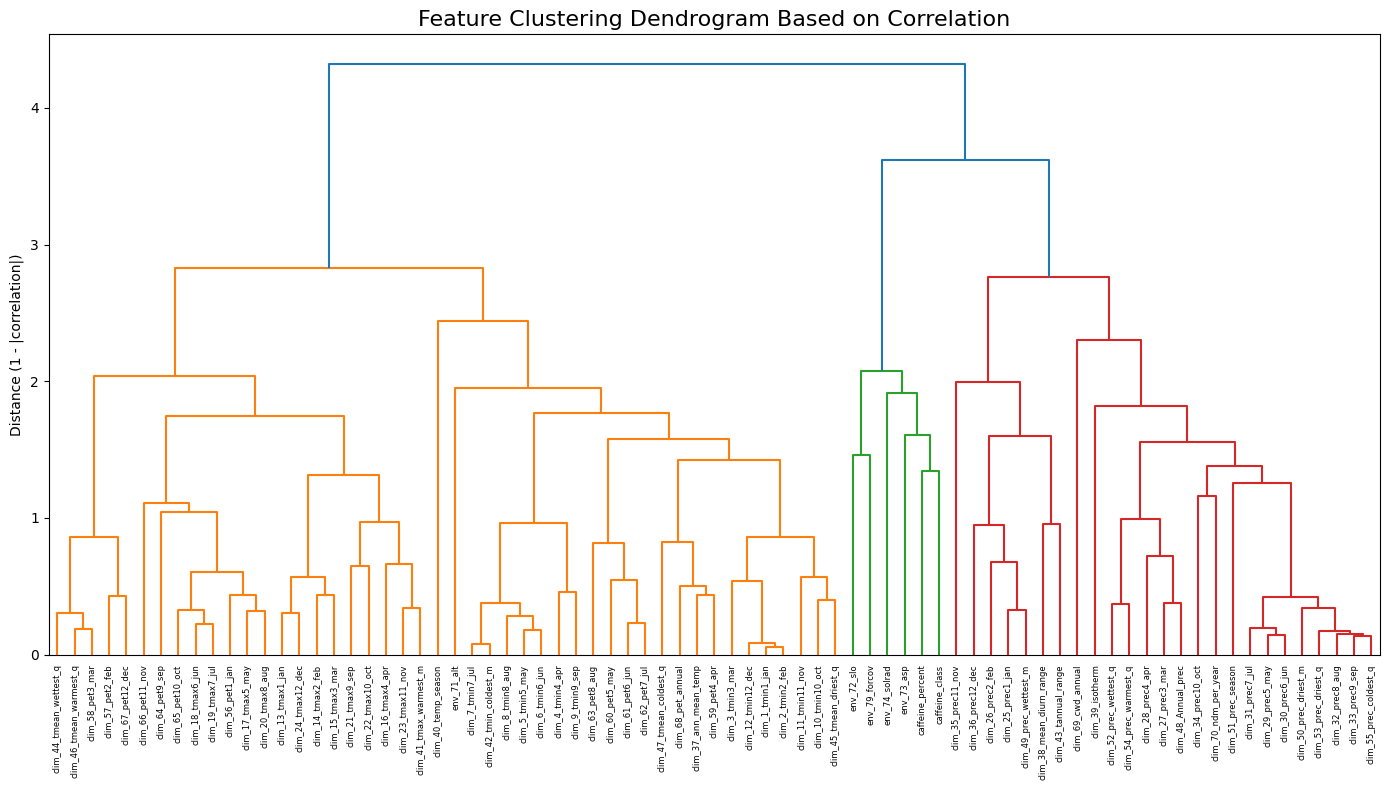

In [69]:
plot_feature_dendrogram(num_data)

In [70]:
# After cleaning (use the output of clean_features function)
df_clean = clean_features(coffee_data, df_num_clean)



Kept 19 continuous, 0 binary, 69 env_cats, and 2 outcomes → total 90 cols.


In [71]:
df_clean.to_csv("../data/reduced_data_bin.csv", index=False)